In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv')

In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [5]:
df.dtypes

,0
CustomerID,int64
Age,int64
Gender,object
Tenure,int64
Usage Frequency,int64
Support Calls,int64
Payment Delay,int64
Subscription Type,object
Contract Length,object
Total Spend,int64


In [6]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [7]:
label_encoder = {}

for col in df.select_dtypes(include = ['object']):
  le = LabelEncoder()
  df[col] = le.fit_transform(df[col].astype('str'))
  label_encoder[col] = le

In [8]:
X = df.drop('Churn', axis = 1)
Y = df['Churn']

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [11]:
model = RandomForestClassifier(n_estimators=100, random_state = 42)
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [12]:
y_pred = model.predict(X_test)

In [17]:
print("Random Forest Classifier Report:\n")
print(classification_report(Y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
print("Accuracy:")
print(accuracy_score(Y_test, y_pred))

Random Forest Classifier Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875

Confusion Matrix:
[[6793    0]
 [  27 6055]]
Accuracy:
0.9979029126213592


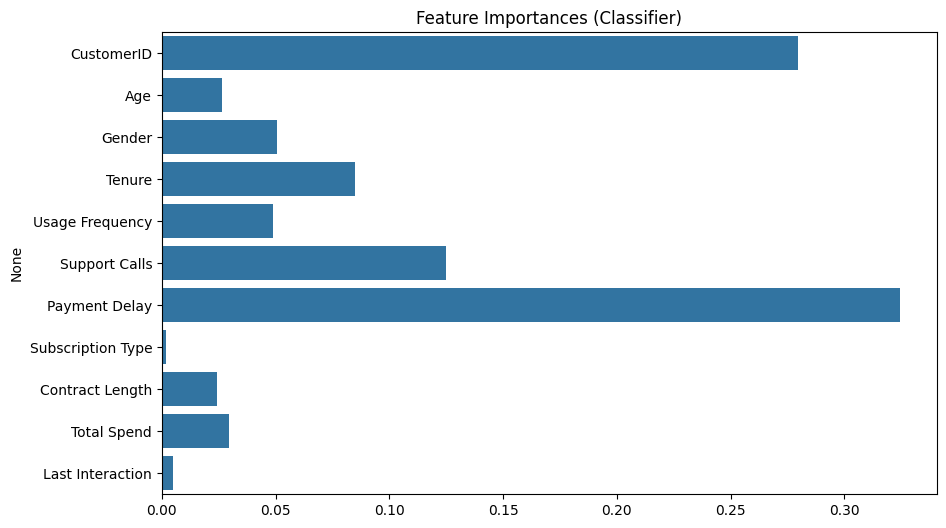

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x=model.feature_importances_, y=X.columns)
plt.title("Feature Importances (Classifier)")
plt.show()

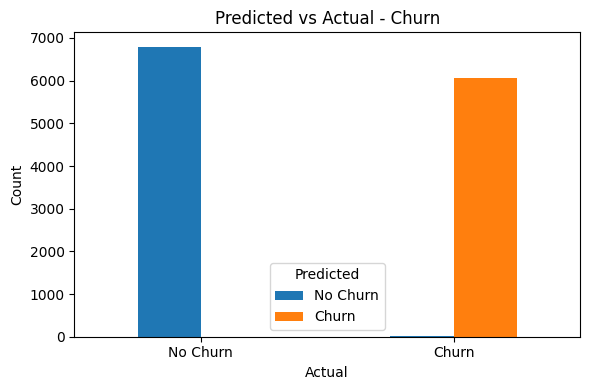

In [24]:

cm = confusion_matrix(Y_test, y_pred)
labels = ['No Churn', 'Churn']

cm_df = pd.DataFrame(cm, index=labels, columns=labels)

cm_df.plot(kind='bar', figsize=(6,4), rot=0)
plt.title('Predicted vs Actual - Churn')
plt.xlabel('Actual')
plt.ylabel('Count')
plt.legend(title='Predicted')
plt.tight_layout()
plt.show()
